In [1]:
import sys
sys.path.append("../src")

In [2]:
from video_io import get_video_info, get_frames
from viz import show_frame, show_keypoints

In [3]:
video_path = "../data/testvideo.mp4"

In [4]:
info = get_video_info(video_path)
frames = get_frames(video_path)

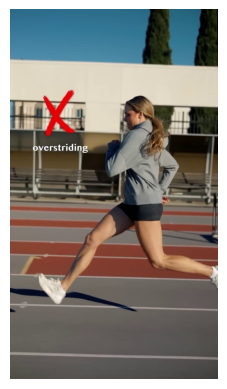

In [5]:
frame = frames[99]
show_frame(frame)

In [7]:
from ultralytics import YOLO

pose_model = YOLO("yolo26n-pose.pt")
pose_model

YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03,

Number of people (boxes): 1
boxes.xyxy shape: torch.Size([1, 4])
keypoints.xy shape: torch.Size([1, 17, 2])
keypoints.conf shape: torch.Size([1, 17])


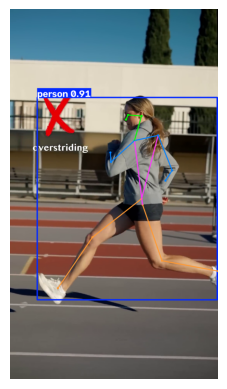

In [8]:
results_my = pose_model.predict(frame, conf=0.25, verbose=False)
r0 = results_my[0]

# how many pepole are detected?
if r0.boxes is not None:
    print("Number of people (boxes):", len(r0.boxes))
    print("boxes.xyxy shape:", r0.boxes.xyxy.shape)

if r0.keypoints is not None:
    print("keypoints.xy shape:", r0.keypoints.xy.shape)     # (N, K, 2)
    print("keypoints.conf shape:", r0.keypoints.conf.shape) # (N, K)
    
annotated_bgr = r0.plot()  # Draws skeleton/keypoints and, if available, boxes
show_frame(annotated_bgr)

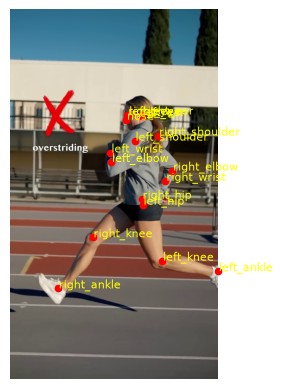

In [9]:
show_keypoints(frame, results_my[0].keypoints.xy[0])